# Dynamic Fare Optimization for Ride-Sharing Platforms

**Business Objective:** A leading ride-sharing company (e.g., Uber, Careem, Lyft) currently prices rides mainly based on expected duration. They want a dynamic pricing model that incorporates real-time supply-demand imbalance, customer profile, time, location, and vehicle type to:
- Increase revenue through dynamic pricing
- Improve fleet allocation during peak hours
- Maintain customer retention (avoid over-pricing)

**Imports**

In [193]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tabulate import tabulate

## 1. Data Loading

In [194]:
dynamic_pricing = pd.read_csv('dynamic_pricing.csv')

In [195]:
dynamic_pricing.head(10)

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422
5,59,35,Urban,Silver,83,3.51,Night,Economy,128,339.955361
6,93,43,Suburban,Regular,44,4.41,Afternoon,Premium,16,104.061541
7,62,39,Rural,Gold,83,3.59,Afternoon,Premium,47,235.811864
8,79,14,Rural,Silver,71,3.74,Evening,Economy,128,501.412517
9,42,6,Rural,Silver,21,3.85,Night,Premium,128,398.993365


In [196]:
dynamic_pricing.info() #data is clean and has no NULLs

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Number_of_Riders         1000 non-null   int64  
 1   Number_of_Drivers        1000 non-null   int64  
 2   Location_Category        1000 non-null   object 
 3   Customer_Loyalty_Status  1000 non-null   object 
 4   Number_of_Past_Rides     1000 non-null   int64  
 5   Average_Ratings          1000 non-null   float64
 6   Time_of_Booking          1000 non-null   object 
 7   Vehicle_Type             1000 non-null   object 
 8   Expected_Ride_Duration   1000 non-null   int64  
 9   Historical_Cost_of_Ride  1000 non-null   float64
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


In [197]:
dynamic_pricing.describe()

,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,60.372000,27.076000,50.031000,4.257220,99.58800,372.502623
std,23.701506,19.068346,29.313774,0.435781,49.16545,187.158756
min,20.000000,5.000000,0.000000,3.500000,10.00000,25.993449
25%,40.000000,11.000000,25.000000,3.870000,59.75000,221.365202
50%,60.000000,22.000000,51.000000,4.270000,102.00000,362.019426
75%,81.000000,38.000000,75.000000,4.632500,143.00000,510.497504
max,100.000000,89.000000,100.000000,5.000000,180.00000,836.116419


## 2. Data Overview and Business Indicators

We define the `Demand_Supply_Ratio` as a strong predictor of ride cost in dynamic pricing systems. 
We expect a strong positive correlation with `Historical_Cost_of_Ride`.

**Definition**: `Number_of_Riders / Number_of_Drivers`

**Business Interpretation**:
- Ratio > 1.5 → High demand (surge pricing opportunity)
- Ratio < 0.8 → Low demand (possible discounts to stimulate demand)

In [198]:
# Create core dynamic pricing metric
dynamic_pricing['Demand_Supply_Ratio'] = dynamic_pricing['Number_of_Riders']/dynamic_pricing['Number_of_Drivers']
dynamic_pricing.head() 

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,2.000000
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,1.487179
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1.354839
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,3.178571
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,3.545455


In [199]:
# Create 4 balanced bins = quantiles based on Demand_Supply_Ratio values distribution. 
# But ideally validate these thresholds with the business team and test different cutoffs using A/B experiments
q = 4
labels = ['Low Demand', 'Moderate', 'High Demand', 'Extreme Surge']
dynamic_pricing['Demande_Quartiles'] = pd.qcut(dynamic_pricing['Demand_Supply_Ratio'],q= q,labels =labels)
dynamic_pricing.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio,Demande_Quartiles
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273,2.000000,Moderate
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753,1.487179,Low Demand
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469,1.354839,Low Demand
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232,3.178571,High Demand
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422,3.545455,High Demand


## 3. Test Set

In [200]:
# We use stratification as a sampling technique to ensure that the train-test split of data maintains the same proportion of class labels as the original dataset
train_set, test_set = train_test_split(dynamic_pricing, test_size = 0.2, random_state = 42, shuffle=True, stratify = dynamic_pricing['Demande_Quartiles'])

In [201]:
# train_set.shape
test_set.shape

(200, 12)

In [202]:
# Check if the ditribution of Demande_Quartiles was preserved across in the training and test sets 
print(train_set['Demande_Quartiles'].value_counts(normalize = True).round(2)) #count the number of unique Demande levels then normalize to get the relative frequencies

Demande_Quartiles
Moderate         0.25
Low Demand       0.25
High Demand      0.25
Extreme Surge    0.25
Name: proportion, dtype: float64


In [203]:
print(test_set['Demande_Quartiles'].value_counts(normalize = True).round(2))

Demande_Quartiles
Low Demand       0.25
Moderate         0.25
High Demand      0.25
Extreme Surge    0.25
Name: proportion, dtype: float64


## 4. Exploratory Data Analysis

In [204]:
# EDA on training data only
pricing = train_set.copy()

**Data Quality Check**

In [205]:
print('Missing Values:')
pricing.isnull().sum() #No null values, which we already checked through dynamic_pricing.info()

Missing Values:


Number_of_Riders           0
Number_of_Drivers          0
Location_Category          0
Customer_Loyalty_Status    0
Number_of_Past_Rides       0
Average_Ratings            0
Time_of_Booking            0
Vehicle_Type               0
Expected_Ride_Duration     0
Historical_Cost_of_Ride    0
Demand_Supply_Ratio        0
Demande_Quartiles          0
dtype: int64

In [206]:
pricing.duplicated().sum() #No duplicated rows

np.int64(0)

**Feature Types Classification**

In [207]:
print('Numerical Features:')
pricing.select_dtypes(include='number').columns.tolist()

Numerical Features:


['Number_of_Riders',
 'Number_of_Drivers',
 'Number_of_Past_Rides',
 'Average_Ratings',
 'Expected_Ride_Duration',
 'Historical_Cost_of_Ride',
 'Demand_Supply_Ratio']

In [208]:
print('Categorical Features:')
pricing.select_dtypes(include=['category','object']).columns.tolist()

Categorical Features:


['Location_Category',
 'Customer_Loyalty_Status',
 'Time_of_Booking',
 'Vehicle_Type',
 'Demande_Quartiles']

**Numerical Distributions**

In [209]:
# Look for extreme values, unexpected zeros, skewed data
print('Numerical Features Summary:')
pricing.select_dtypes(include='number').describe().round(2)

Numerical Features Summary:


,Number_of_Riders,Number_of_Drivers,Number_of_Past_Rides,Average_Ratings,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,59.70,26.88,50.51,4.27,100.26,375.47,3.22
std,24.03,19.27,29.36,0.44,49.68,189.99,2.52
min,20.00,5.00,0.00,3.50,10.00,25.99,1.11
25%,38.00,11.00,25.00,3.89,60.00,226.50,1.66
50%,59.00,21.00,51.00,4.28,103.00,361.42,2.36
75%,81.25,37.00,75.25,4.66,144.00,514.21,3.79
max,100.00,89.00,100.00,5.00,180.00,836.12,17.60


array([[<Axes: title={'center': 'Number_of_Riders'}>,
        <Axes: title={'center': 'Number_of_Drivers'}>,
        <Axes: title={'center': 'Number_of_Past_Rides'}>],
       [<Axes: title={'center': 'Average_Ratings'}>,
        <Axes: title={'center': 'Expected_Ride_Duration'}>,
        <Axes: title={'center': 'Historical_Cost_of_Ride'}>],
       [<Axes: title={'center': 'Demand_Supply_Ratio'}>, <Axes: >,
        <Axes: >]], dtype=object)

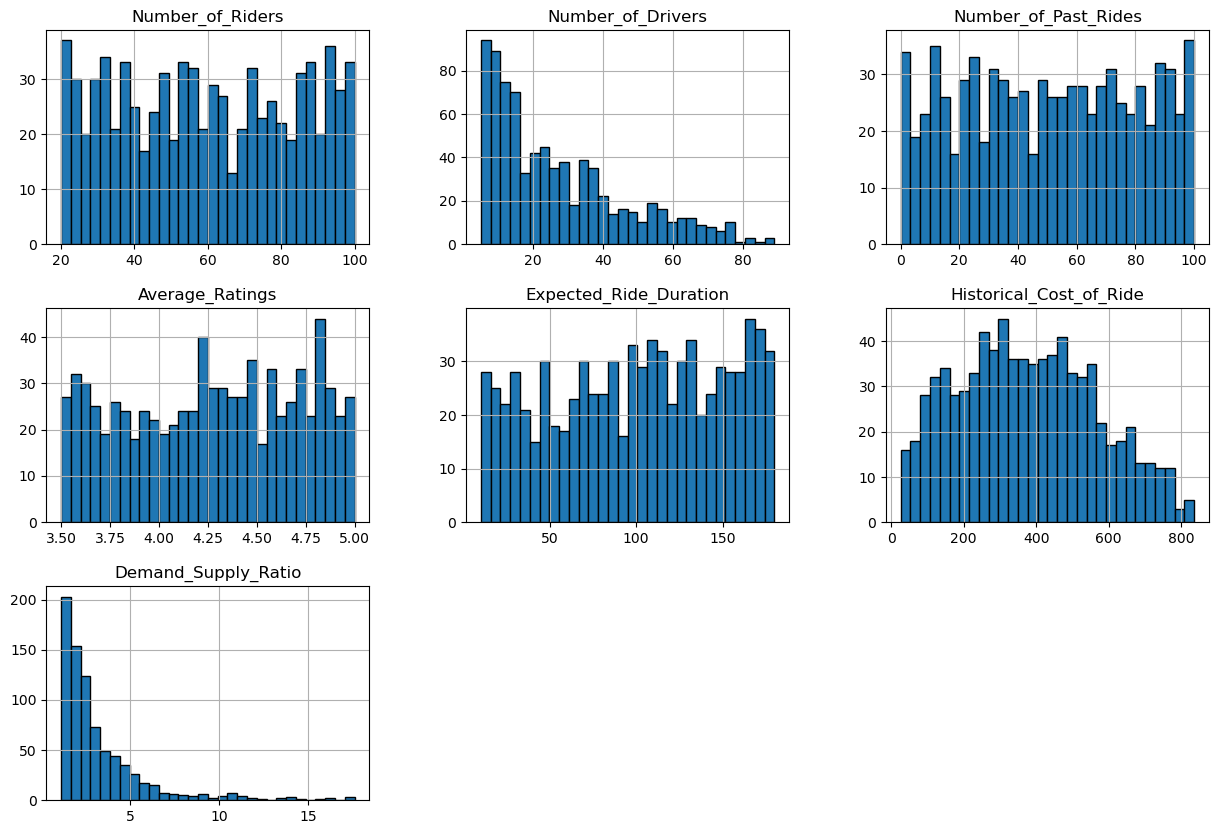

In [210]:
pricing.select_dtypes(include='number').hist(bins=30, figsize=(15, 10), edgecolor='black')

In [211]:
print('Categorical Features Summary:')
pricing.select_dtypes(include=['category','object']).describe() # freq: The number of times that top value appears in the     

Categorical Features Summary:


,Location_Category,Customer_Loyalty_Status,Time_of_Booking,Vehicle_Type,Demande_Quartiles
count,800,800,800,800,800
unique,3,3,4,2,4
top,Urban,Silver,Night,Premium,Moderate
freq,272,294,221,407,201


In [212]:
pricing.select_dtypes(include=['category','object']).select_dtypes(include=['category','object']).value_counts(normalize = True).round(2)

Location_Category  Customer_Loyalty_Status  Time_of_Booking  Vehicle_Type  Demande_Quartiles
Urban              Silver                   Night            Premium       Moderate             0.01
Suburban           Regular                  Evening          Premium       Moderate             0.01
Urban              Silver                   Night            Economy       Extreme Surge        0.01
Rural              Gold                     Evening          Premium       Low Demand           0.01
Suburban           Silver                   Morning          Economy       Moderate             0.01
                                                                                                ... 
Rural              Regular                  Evening          Economy       Moderate             0.00
                                            Afternoon        Economy       Extreme Surge        0.00
Suburban           Gold                     Evening          Premium       Moderate             0.0

**Outlier Detection**

The histograms in the Numerical Distributions section do not show a number of extreme values that are stretching the x-axis negative values. Our assumption is this dataset will not need cleaning but let us dig deeper by 

In [213]:
# Let us remove outliers using IQR method
for column in pricing.select_dtypes(include='number').columns:
    Q1 = pricing[column].quantile(0.25)
    Q3 = pricing[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers = pricing[(pricing[column]<lower_bound) | (pricing[column]>upper_bound)]

In [214]:
outliers_cnt = len(outliers)
outliers_cnt

56

In [215]:
outliers_pct = round((outliers_cnt/len(pricing) *100),2)
print(f"{outliers_pct} % outliers in the dataset")

7.0 % outliers in the dataset


In dynamic pricing / ride-sharing data, outliers might be real and meaningful (extreme surge periods, very long rides, special events, etc.). We'll decide the best treatment during the preprocessing/feature engineering stage.

In [216]:
pricing.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio,Demande_Quartiles
64,79,64,Rural,Regular,91,4.57,Night,Economy,164,666.687029,1.234375,Low Demand
935,92,31,Rural,Silver,54,3.91,Night,Premium,148,516.133039,2.967742,High Demand
227,53,40,Rural,Gold,79,3.66,Evening,Premium,30,158.652642,1.325000,Low Demand
400,62,11,Suburban,Gold,37,4.23,Morning,Premium,71,363.345753,5.636364,Extreme Surge
323,55,19,Suburban,Silver,74,3.51,Morning,Economy,173,702.913416,2.894737,High Demand


**Bivariate Analysis**

In [217]:
key_features =['Location_Category','Customer_Loyalty_Status','Number_of_Past_Rides','Average_Ratings','Time_of_Booking','Vehicle_Type','Expected_Ride_Duration','Demand_Supply_Ratio']

axes is a matrix of x rows by y columns containing x*y subplot axes objects
array([[ <Axes: >, <Axes: >, <Axes: > ],# Row 0
[ <Axes: >, <Axes: >, <Axes: > ]])    # Row 1

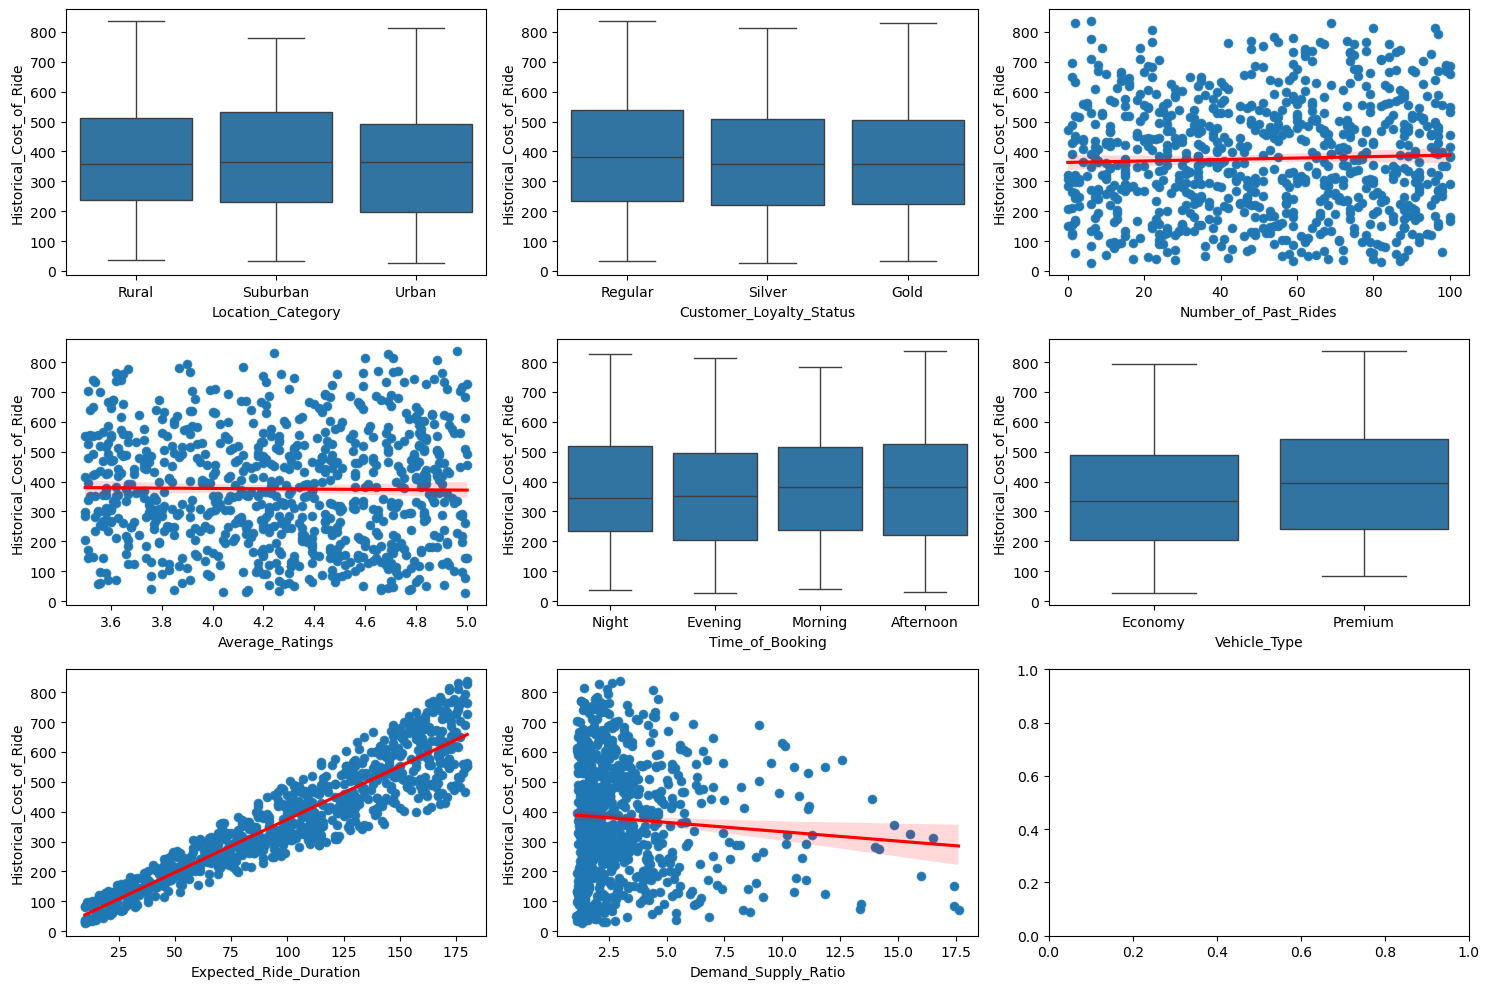

In [218]:
fig, axes = plt.subplots(3,3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    # Numerical Features vs Target (numerical) => Scatter plot to see the relationships between the variables + regression line 
    if feature in ['Number_of_Past_Rides','Average_Ratings','Expected_Ride_Duration','Demand_Supply_Ratio']:
        # visualize the relationship between the Target variable and the other num variables
        sns.scatterplot(data=pricing, x=feature, y='Historical_Cost_of_Ride', ax=axes[i])
        sns.regplot(data=pricing, x=feature, y='Historical_Cost_of_Ride', ax=axes[i],line_kws={"color": "red"})
    # Categorical Features vs Tagert (numerical) => Box plot to see the distibution of a numerical variable across categorical groups 
    else:
        sns.boxplot(data=pricing, x=feature, y='Historical_Cost_of_Ride', ax=axes[i]) #read about difference with catplot + kind = 'box'
plt.tight_layout()
plt.show()

**Correlation**

In [219]:
num_features = pricing.select_dtypes(include=['int64','float64'])

<Axes: >

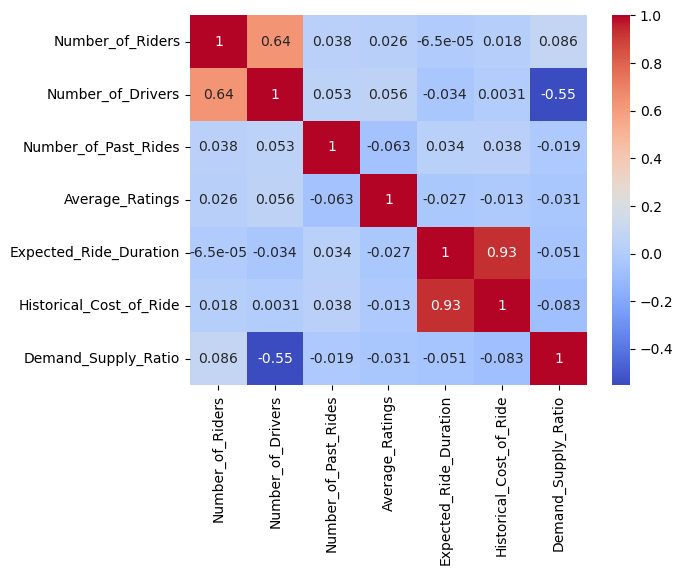

In [220]:
corr = num_features.corr()
sns.heatmap(corr,annot=True, cmap='coolwarm')

## 5. Feature Engineering

We already created a Demand_Supply_Ratio and Demande_Quartiles features

In [221]:
pricing['Time_of_Booking'].unique()

array(['Night', 'Evening', 'Morning', 'Afternoon'], dtype=object)

We assume that the ride fair increasing past 9pm, i.e. at night.

In [222]:
pricing['Is_Peak_hour'] = pricing['Time_of_Booking'].isin(['Evening', 'Morning', 'Afternoon']).astype(int)

In [223]:
pricing['Is_Night_hour'] = pricing['Time_of_Booking'].isin(['Night']).astype(int)

In [224]:
pricing.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio,Demande_Quartiles,Is_Peak_hour,Is_Night_hour
64,79,64,Rural,Regular,91,4.57,Night,Economy,164,666.687029,1.234375,Low Demand,0,1
935,92,31,Rural,Silver,54,3.91,Night,Premium,148,516.133039,2.967742,High Demand,0,1
227,53,40,Rural,Gold,79,3.66,Evening,Premium,30,158.652642,1.325000,Low Demand,1,0
400,62,11,Suburban,Gold,37,4.23,Morning,Premium,71,363.345753,5.636364,Extreme Surge,1,0
323,55,19,Suburban,Silver,74,3.51,Morning,Economy,173,702.913416,2.894737,High Demand,1,0


More loyal customers get discounted prices to encourage demand

In [225]:
pricing['Customer_Loyalty_Status'].unique()

array(['Regular', 'Silver', 'Gold'], dtype=object)

In [226]:
pricing['Loyalty_Multiplier'] = 0.0

In [227]:
pricing.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio,Demande_Quartiles,Is_Peak_hour,Is_Night_hour,Loyalty_Multiplier
64,79,64,Rural,Regular,91,4.57,Night,Economy,164,666.687029,1.234375,Low Demand,0,1,0.0
935,92,31,Rural,Silver,54,3.91,Night,Premium,148,516.133039,2.967742,High Demand,0,1,0.0
227,53,40,Rural,Gold,79,3.66,Evening,Premium,30,158.652642,1.325000,Low Demand,1,0,0.0
400,62,11,Suburban,Gold,37,4.23,Morning,Premium,71,363.345753,5.636364,Extreme Surge,1,0,0.0
323,55,19,Suburban,Silver,74,3.51,Morning,Economy,173,702.913416,2.894737,High Demand,1,0,0.0


In [228]:
for index, row in pricing.iterrows():
    if row['Customer_Loyalty_Status'] == 'Regular':
        pricing.loc[index, 'Loyalty_Multiplier'] = 1.0
    elif row['Customer_Loyalty_Status'] == 'Silver':
        pricing.loc[index, 'Loyalty_Multiplier'] = 0.95 
    else :
        pricing.loc[index, 'Loyalty_Multiplier'] = 0.90

In [229]:
pricing['Ride_Efficiency']= pricing['Expected_Ride_Duration']/(pricing['Number_of_Riders'] + 1e-7)

In [230]:
pricing.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride,Demand_Supply_Ratio,Demande_Quartiles,Is_Peak_hour,Is_Night_hour,Loyalty_Multiplier,Ride_Efficiency
64,79,64,Rural,Regular,91,4.57,Night,Economy,164,666.687029,1.234375,Low Demand,0,1,1.00,2.075949
935,92,31,Rural,Silver,54,3.91,Night,Premium,148,516.133039,2.967742,High Demand,0,1,0.95,1.608696
227,53,40,Rural,Gold,79,3.66,Evening,Premium,30,158.652642,1.325000,Low Demand,1,0,0.90,0.566038
400,62,11,Suburban,Gold,37,4.23,Morning,Premium,71,363.345753,5.636364,Extreme Surge,1,0,0.90,1.145161
323,55,19,Suburban,Silver,74,3.51,Morning,Economy,173,702.913416,2.894737,High Demand,1,0,0.95,3.145455


How the model will learn to adjust prices based on these newly defined features ?

| Feature                | Description                                      | Expected Price Impact                          | Business Logic |
|------------------------|--------------------------------------------------|------------------------------------------------|--------------|
| Is_Peak_Hour      | Morning (7-10) or Evening (5-8)                 | Higher                                     | Surge during high commuting demand |
| Is_Night_Hour    | Night time (after 8pm)                           | Higher                                    | Lower supply + safety premium |
| Loyalty_Multiplier| Discount factor (Gold = 0.90, Silver = 0.95)    | Lower for loyal customers                  | Rewards retention & lifetime value |
| Ride_Efficiency    | Expected duration per rider                      | Higher when value is high                  | Longer/less shared rides cost more |

The model will learn to dynamically adjust fares by combining these signals:
- Increase price during peak and night hours due to higher demand / lower supply.
- Offer discounts to loyal (Gold/Silver) customers to improve retention.
- Charge more for low-efficiency rides (long duration with few riders) as they are less economical to serve.



## 6. Data Preparation

In [231]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

We group the features into numerical, categorical and binary and drop some previously engineered features not because they carry no information, but because the information is already present in other columns and in a form the models can use

In [253]:
numerical_features = ['Expected_Ride_Duration', 'Demand_Supply_Ratio', 'Ride_Efficiency',
                      'Number_of_Past_Rides', 'Average_Ratings','Number_of_Riders', 
    'Number_of_Drivers' ]

categorical_features = ['Location_Category', 'Vehicle_Type', 'Time_of_Booking',
                        'Customer_Loyalty_Status']

In [254]:
num_imputation = SimpleImputer(missing_values=np.nan, strategy='median')
cat_imputation = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

In [255]:
num_transformer = Pipeline(steps= [('imputer',num_imputation), ('scaler',StandardScaler())])
cat_transformer = Pipeline(steps= [('imputer',cat_imputation), ('onehot',OneHotEncoder(handle_unknown='ignore', sparse_output = False))])

In [256]:
preprocessor = ColumnTransformer(
    transformers = [
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
    ])

In [257]:
from sklearn.model_selection import train_test_split

In [258]:
X_train = pricing.drop('Historical_Cost_of_Ride', axis=1)
y_train = pricing['Historical_Cost_of_Ride']

In [259]:
X_train.shape

(800, 15)

In [260]:
X_train.head()

,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Demand_Supply_Ratio,Demande_Quartiles,Is_Peak_hour,Is_Night_hour,Loyalty_Multiplier,Ride_Efficiency
64,79,64,Rural,Regular,91,4.57,Night,Economy,164,1.234375,Low Demand,0,1,1.00,2.075949
935,92,31,Rural,Silver,54,3.91,Night,Premium,148,2.967742,High Demand,0,1,0.95,1.608696
227,53,40,Rural,Gold,79,3.66,Evening,Premium,30,1.325000,Low Demand,1,0,0.90,0.566038
400,62,11,Suburban,Gold,37,4.23,Morning,Premium,71,5.636364,Extreme Surge,1,0,0.90,1.145161
323,55,19,Suburban,Silver,74,3.51,Morning,Economy,173,2.894737,High Demand,1,0,0.95,3.145455


## 7. Model Selection

In [261]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [262]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error', 'r2']
results = {}

def score_model(name, model):
    pipe = Pipeline([('prep',preprocessor), ('model',model)])
    cvr = cross_validate(pipe, X_train, y_train, scoring =scoring, cv=cv, n_jobs=-1)
    results[name] = {
        'RMSE': - cvr['test_neg_root_mean_squared_error'].mean(),
    }

**MODEL 01: Linear Regression**

In [263]:
linear_reg = score_model('Linear Regression', LinearRegression())

**MODEL 02: Random Forest**

In [264]:
random_forest = score_model('Random Forest', RandomForestRegressor(n_estimators=300, random_state=42))

**MODEL 03: Gradient Boosting**

In [265]:
gradient_boost = score_model('Gradient Boost', GradientBoostingRegressor(n_estimators=300, random_state=42))

In [266]:
results

{'Linear Regression': {'RMSE': np.float64(67.30639758246149)},
 'Random Forest': {'RMSE': np.float64(70.437775210019)},
 'Gradient Boost': {'RMSE': np.float64(70.99219789443858)}}

Linear Regression model shows the least RMSE score

Since the feature engineering step was not applied to the whole dataset, we add the following step:

In [275]:
def create_features(df):
    df = df.copy()
    df['Demand_Supply_Ratio'] = df['Number_of_Riders'] / df['Number_of_Drivers']
    df['Demande_Quartiles'] = pd.qcut(df['Demand_Supply_Ratio'], q=4,labels=['Low Demand', 'Moderate', 'High Demand', 'Extreme Surge'])
    df['Is_Peak_hour'] = df['Time_of_Booking'].isin(['Morning', 'Evening', 'Afternoon']).astype(int)
    df['Is_Night_hour'] = (df['Time_of_Booking'] == 'Night').astype(int)
    df['Loyalty_Multiplier'] = df['Customer_Loyalty_Status'].map({
        'Regular': 1.00,
        'Silver':  0.95,
        'Gold':    0.90})
    df['Ride_Efficiency'] = df['Expected_Ride_Duration'] / (df['Number_of_Riders'] + 1e-7)
    
    return df

In [276]:
dynamic_pricing = create_features(dynamic_pricing)

In [277]:
train_set, test_set = train_test_split(dynamic_pricing, test_size=0.2, random_state=42, stratify=dynamic_pricing['Demande_Quartiles'])

In [281]:
X_train = train_set.drop('Historical_Cost_of_Ride', axis=1)
y_train = train_set['Historical_Cost_of_Ride']

In [282]:
X_test = test_set.drop('Historical_Cost_of_Ride', axis=1)
y_test = test_set['Historical_Cost_of_Ride']

In [283]:
final_model = Pipeline([('prep',preprocessor), ('Linear Regression', LinearRegression())])

In [284]:
final_model.fit(X_train, y_train)

,steps,"[('prep', ...), ('Linear Regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [285]:
y_predict = final_model.predict(X_test)

In [286]:
final_model.score(X_train,y_train)*100

87.92298686983727

In [287]:
final_model.score(X_test,y_test)*100

86.56653432815816